# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

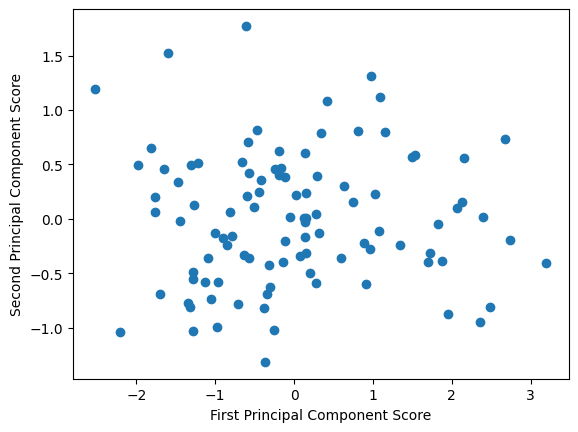

In [13]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

### Instacart Market Basket Analysis Dataset

The Instacart Market Basket Analysis dataset contains transaction level records describing how customers build their grocery baskets over time. Each row in the order product data represents a single product that was added to a specific order. Order level information from the orders table was combined with product metadata to support behavioral analysis.

The main variables used in this notebook are summarized below.

- **order_id** – Unique identifier for each order placed on Instacart.
- **user_id** – Unique identifier for each customer.
- **product_id** – Unique identifier for each product purchased.
- **product_name** – Name of the product associated with the product ID.

- **add_to_cart_order** – The sequence position in which the product was added to the cart within an order.
- **reordered** – Binary indicator showing whether the product had been purchased previously by the same user.

- **order_number** – The number representing a customer's order history (first order, second order, etc.).
- **order_dow** – The day of the week the order was placed.
- **order_hour_of_day** – The hour of the day the order was placed.
- **days_since_prior_order** – Number of days since the customer’s previous order.

The analysis also includes several derived features:

- **basket_size** – Total number of items in an order.
- **reorder_rate** – Proportion of items in an order that were previously purchased by the same customer.
- **avg_add_to_cart_order** – The average cart position of items in an order, which reflects how items are added during the shopping process.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download dataset
path2 = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:", path2)

instacart_dir = Path(path2)
print("Instacart dataset folder:", instacart_dir)

100%|██████████| 197M/197M [00:01<00:00, 143MB/s]  

Extracting files...


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1
Instacart dataset folder: /home/codespace/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1


In [3]:
# Load manageable files fully
orders = pd.read_csv(
    instacart_dir / "orders.csv",
    usecols=["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"]
)

products = pd.read_csv(instacart_dir / "products.csv")

print("orders shape:", orders.shape)
print("products shape:", products.shape)

display(orders.head())
display(products.head())

orders shape: (3421083, 6)
products shape: (49688, 4)


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [4]:
# Sample a manageable subset of orders
sample_orders = orders.sample(n=10000, random_state=42)
sample_order_ids = set(sample_orders["order_id"].astype(int))

print("Number of sampled order IDs:", len(sample_order_ids))

# Load only matching rows from the large file using chunks
usecols = ["order_id", "product_id", "add_to_cart_order", "reordered"]

chunks = []
for chunk in pd.read_csv(
    instacart_dir / "order_products__prior.csv",
    usecols=usecols,
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16",
        "reordered": "int8",
    },
    chunksize=200_000
):
    filtered = chunk[chunk["order_id"].isin(sample_order_ids)]
    if not filtered.empty:
        chunks.append(filtered)

sample_order_products = pd.concat(chunks, ignore_index=True)

print("sample_order_products shape:", sample_order_products.shape)
display(sample_order_products.head())

Number of sampled order IDs: 10000
sample_order_products shape: (96603, 4)


,order_id,product_id,add_to_cart_order,reordered
0,322,13819,1,1
1,322,432,2,1
2,322,19311,3,1
3,322,36646,4,0
4,322,28842,5,1


In [5]:
# Merge sampled order-product data with product metadata
instacart_sample = sample_order_products.merge(products, on="product_id", how="left")

print("instacart_sample shape:", instacart_sample.shape)
display(instacart_sample.head())

instacart_sample shape: (96603, 7)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,322,13819,1,1,Roasted Salted Cashews,117,19
1,322,432,2,1,Vanilla Almond Breeze Almond Milk,91,16
2,322,19311,3,1,Almond Flour Tortillas,128,3
3,322,36646,4,0,Lactose Free Sour Cream,108,16
4,322,28842,5,1,Bunched Cilantro,16,4


In [8]:
# Basket size (items per order)
basket_size = instacart_sample.groupby("order_id").size().reset_index(name="basket_size")

# Reorder rate per order
reorder_rate = instacart_sample.groupby("order_id")["reordered"].mean().reset_index(name="reorder_rate")

# Average add-to-cart order
avg_add_to_cart = instacart_sample.groupby("order_id")["add_to_cart_order"].mean().reset_index(name="avg_add_to_cart_order")

# Merge with orders dataset
instacart_features = basket_size.merge(reorder_rate, on="order_id")
instacart_features = instacart_features.merge(avg_add_to_cart, on="order_id")
instacart_features = instacart_features.merge(orders, on="order_id")

# Clean dataset
instacart_features = instacart_features.dropna()
display(instacart_features.head())

,order_id,basket_size,reorder_rate,avg_add_to_cart_order,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,322,9,0.444444,5.0,36278,2,1,9,7.0
1,520,9,0.666667,5.0,165200,13,3,8,0.0
2,590,1,1.000000,1.0,198502,31,4,18,7.0
3,816,3,0.333333,2.0,112686,9,0,15,1.0
4,1084,14,0.642857,7.5,131593,41,0,12,7.0


## Heatmap

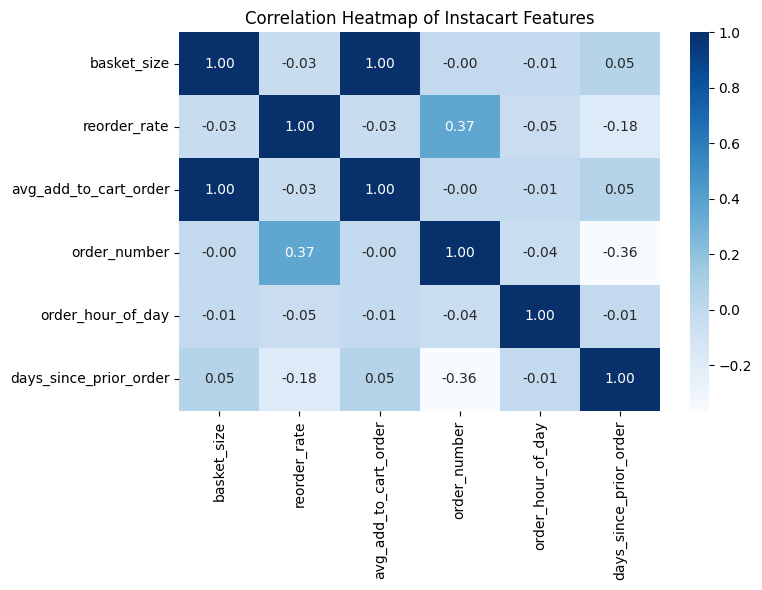

In [12]:
# Features for Plotting and PCA
features = [
    "basket_size",
    "reorder_rate",
    "avg_add_to_cart_order",
    "order_number",
    "order_hour_of_day",
    "days_since_prior_order"
]

plt.figure(figsize=(8,6))
sns.heatmap(instacart_features[features].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Instacart Features")
plt.tight_layout()
plt.show()

The correlation heatmap shows that most variables have weak relationships with one another, indicating that they capture different aspects of customer purchasing behavior. One notable exception is the near-perfect correlation between basket size and average add-to-cart order, which is expected since both variables are derived from order composition. Overall, the lack of strong correlations suggests that multiple features may be needed together to effectively model purchasing behavior.

# Bubble Plot

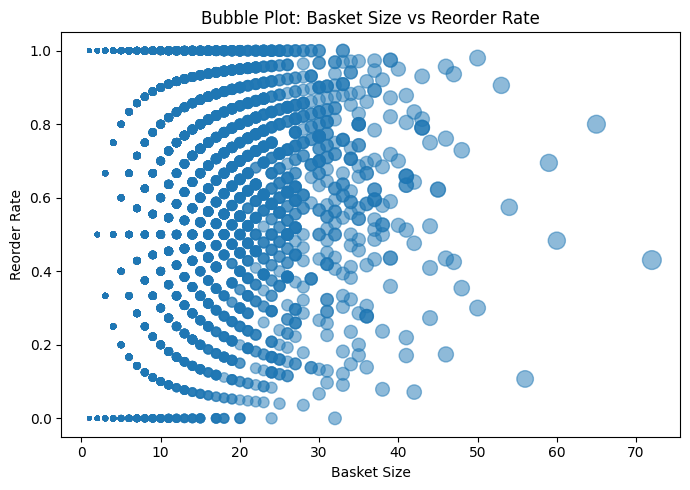

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(
    instacart_features["basket_size"],
    instacart_features["reorder_rate"],
    s=instacart_features["avg_add_to_cart_order"] * 5,
    alpha=0.5
)

plt.xlabel("Basket Size")
plt.ylabel("Reorder Rate")
plt.title("Bubble Plot: Basket Size vs Reorder Rate")
plt.tight_layout()
plt.show()

The bubble plot illustrates the relationship between basket size and reorder rate while incorporating average add-to-cart order as the bubble size. The plot shows that reorder behavior varies across different basket sizes, with no clear linear relationship between the two variables. Larger baskets tend to show more spread in reorder rates, suggesting that customer behavior becomes more variable as order size increases.

## PCA

Explained variance by each component:
[3.35646163e-01 2.68073253e-01 1.67437594e-01 1.34801977e-01
 9.40410137e-02 7.40064927e-17]


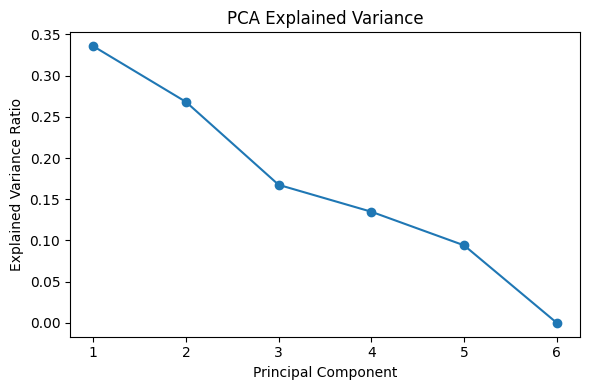

In [15]:
X = instacart_features[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("Explained variance by each component:")
print(explained_variance)

# Plot PCA explained variance
plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.tight_layout()
plt.show()

The PCA results show that the first principal component explains approximately 33.6 percent of the total variance, while the second explains about 26.8 percent. Together, the first two components capture around 60 percent of the variance in the dataset. This indicates that a reduced representation of the data using one or two principal components could still retain a substantial amount of information, although some variability would be lost.

## Linear Regression

In [16]:
X_reg = instacart_features[["basket_size", "order_number", "days_since_prior_order"]]
y_reg = instacart_features["reorder_rate"]

model = LinearRegression()
model.fit(X_reg, y_reg)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-0.00119296  0.00601245 -0.00189404]
Intercept: 0.5603175220371757


The linear regression results show very small coefficients for all input features, indicating that basket size, order number, and time between orders have limited predictive power for reorder rate when considered individually. This aligns with earlier findings that reorder behavior is influenced by multiple factors and cannot be easily explained by a single variable or simple linear relationship.

Overall, the variables show realistic patterns of customer purchasing behavior, including variability in basket size and reorder activity. While some outliers are present, particularly in larger basket sizes, these reflect natural differences in customer behavior rather than data quality issues. The PCA results suggest that the dataset can be partially represented using fewer dimensions, although multiple components are needed to retain most of the variance. Additionally, the regression analysis indicates that no single feature strongly predicts reorder behavior, reinforcing the idea that purchasing patterns are complex and influenced by multiple factors.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

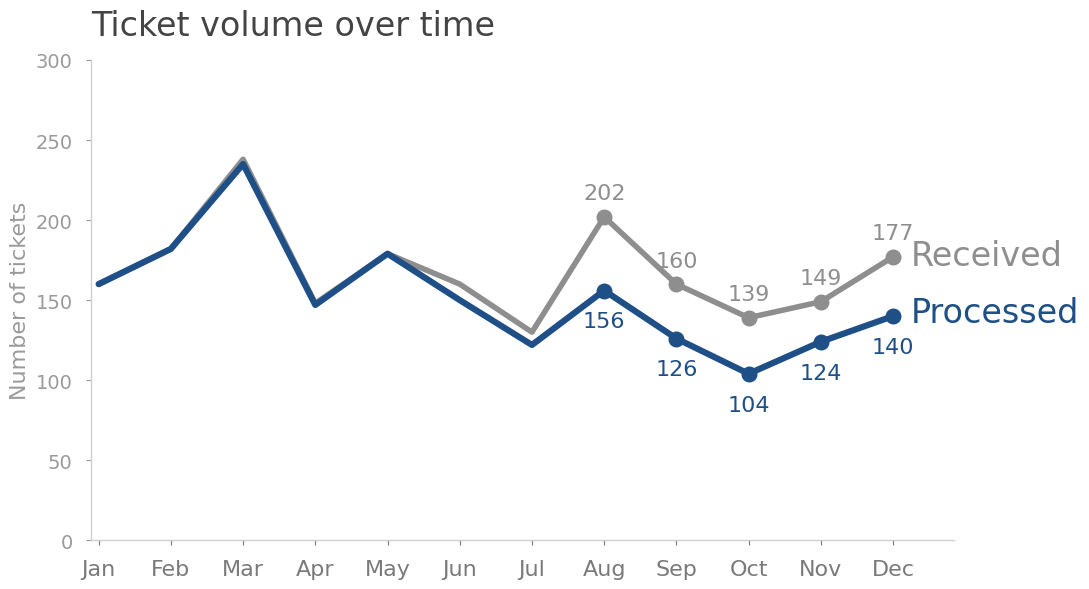

In [ ]:
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
received = [160, 182, 238, 148, 179, 160, 130, 202, 160, 139, 149, 177]
processed = [160, 182, 235, 147, 179, 150, 122, 156, 126, 104, 124, 140]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

received_color = '#8e8e8e'
processed_color = '#1f4f87'

ax.plot(months, received, color=received_color, linewidth=4, solid_capstyle='round')
ax.plot(months, processed, color=processed_color, linewidth=4.5, solid_capstyle='round')

ax.scatter(months[7:], received[7:], color=received_color, s=110, zorder=5)
ax.scatter(months[7:], processed[7:], color=processed_color, s=110, zorder=6)

# Series labels at the right edge.
ax.text(11.25, 178, 'Received', color=received_color, fontsize=24, va='center')
ax.text(11.25, 142, 'Processed', color=processed_color, fontsize=24, va='center')

# Value labels for the annotated right-hand portion.
for month_index, value in zip([7, 8, 9, 10, 11], [202, 160, 139, 149, 177]):
    ax.text(month_index, value + 11, str(value), color=received_color, fontsize=16, ha='center')
for month_index, value in zip([7, 8, 9, 10, 11], [156, 126, 104, 124, 140]):
    ax.text(month_index, value - 13, str(value), color=processed_color, fontsize=16, ha='center', va='top')

ax.set_title('Ticket volume over time', loc='left', fontsize=24, color='#444444', pad=18)
ax.set_ylabel('Number of tickets', fontsize=16, color='#9a9a9a')
ax.set_ylim(0, 300)
ax.set_xlim(-0.1, 11.85)
ax.set_yticks([0, 50, 100, 150, 200, 250, 300])
ax.tick_params(axis='x', labelsize=16, colors='#7a7a7a', pad=10)
ax.tick_params(axis='y', labelsize=14, colors='#9a9a9a', pad=10)

# Remove plot box outline  
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#d0d0d0')
ax.spines['bottom'].set_color('#d0d0d0')
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

plt.tight_layout()
plt.show()